# K-Nearest Neighbors (KNN) — From Intuition to Code

Every model we've studied so far has a **training phase** — a period where the algorithm crunches through the data, learns patterns, and stores those patterns as weights, splits, or probability distributions.

KNN does **none of that**.

It literally just memorizes the entire training dataset and waits. When you ask it to predict a new data point, it looks at the new point, finds the closest points it has memorized, and copies their answer.

It is the simplest, most intuitive algorithm in all of Machine Learning. And despite its simplicity, it is surprisingly powerful.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported!")

Libraries imported!


---
## 1. The Intuition: "Show Me Your Friends"

Imagine you move to a brand new neighborhood and you don't know anything about the area. You want to figure out if your street is a "quiet" street or a "noisy" street.

What do you do? You look at the **K nearest houses** around you:
- If 4 out of 5 of the nearest houses are quiet → Your street is probably **quiet**.
- If 3 out of 5 of the nearest houses are noisy → Your street is probably **noisy**.

That's literally it. KNN says: **"You are what your neighbors are."**

There is **no model**. There are **no weights**. There is **no training**. It just compares a new data point to the existing data points and takes a majority vote from the K closest ones.

This is why KNN is called a **"Lazy Learner"** — it does zero work during training (it literally just stores the data), and does ALL the work during prediction.

---
## 2. The Algorithm: Step by Step

Given a new, unseen data point $x_{\text{new}}$:

1. **Calculate the distance** from $x_{\text{new}}$ to every single row in the training data.
2. **Sort** all rows by distance (closest first).
3. **Pick the top K** closest rows (the K Nearest Neighbors).
4. **Take a majority vote** among those K neighbors.
   - For **Classification**: The most common class among the K neighbors wins.
   - For **Regression**: The average value of the K neighbors is the prediction.

That's the whole algorithm. No gradients, no splits, no probability distributions.

---
## 3. But How Do We Measure "Distance"?

The entire algorithm depends on one thing: measuring how "close" two data points are. There are multiple distance formulas, but the most important ones are:

### Euclidean Distance (Most Common)
The straight-line distance between two points. Think of the distance formula from high school math.

$$d(a, b) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}$$

For 2D, this is just $\sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$ — the Pythagorean theorem!

### Manhattan Distance
Instead of flying in a straight line (Euclidean), imagine you're walking through a city with a grid of streets. You can only walk in straight lines along the blocks — no cutting through buildings!

$$d(a, b) = \sum_{i=1}^{n} |a_i - b_i|$$

### Minkowski Distance (Generalized)
Both Euclidean and Manhattan are just special cases of the Minkowski Distance:

$$d(a, b) = \left(\sum_{i=1}^{n} |a_i - b_i|^p\right)^{1/p}$$

- $p = 1$ → Manhattan Distance
- $p = 2$ → Euclidean Distance

In [2]:
# Let's see these distance metrics in action
point_a = np.array([1, 2])
point_b = np.array([4, 6])

# Euclidean (straight line)
euclidean = np.sqrt(np.sum((point_a - point_b) ** 2))

# Manhattan (city block)
manhattan = np.sum(np.abs(point_a - point_b))

print(f"Point A: {point_a}")
print(f"Point B: {point_b}")
print(f"")
print(f"Euclidean Distance: {euclidean:.4f}  (straight line: √(3² + 4²) = √25 = 5)")
print(f"Manhattan Distance: {manhattan:.4f}  (city blocks: |3| + |4| = 7)")

Point A: [1 2]
Point B: [4 6]

Euclidean Distance: 5.0000  (straight line: √(3² + 4²) = √25 = 5)
Manhattan Distance: 7.0000  (city blocks: |3| + |4| = 7)


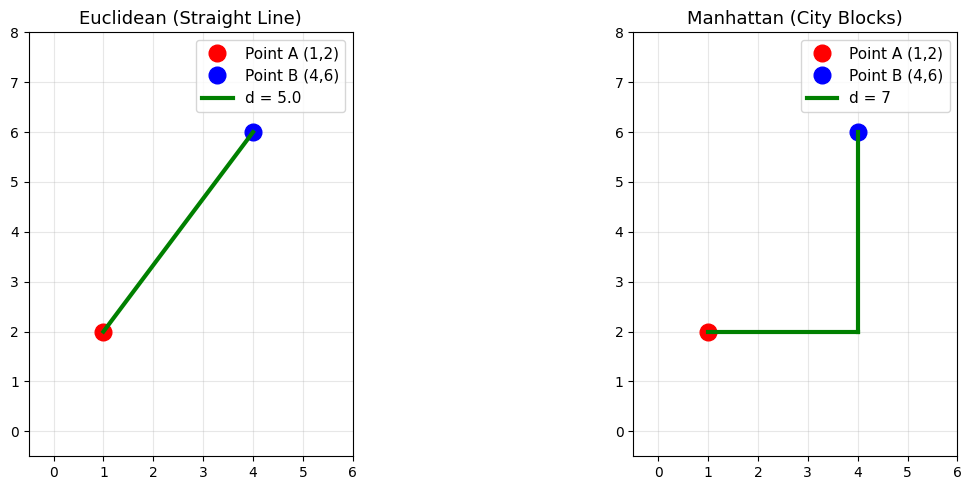

In [4]:
# Visualize the difference between Euclidean and Manhattan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title in zip(axes, ['Euclidean (Straight Line)', 'Manhattan (City Blocks)']):
    ax.plot(*point_a, 'ro', markersize=12, label='Point A (1,2)')
    ax.plot(*point_b, 'bo', markersize=12, label='Point B (4,6)')
    ax.set_xlim(-0.5, 6)
    ax.set_ylim(-0.5, 8)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# Euclidean: straight line
axes[0].plot([1, 4], [2, 6], 'g-', linewidth=3, label=f'd = {euclidean:.1f}')
axes[0].legend(fontsize=11)

# Manhattan: right-angle path
axes[1].plot([1, 4], [2, 2], 'g-', linewidth=3)
axes[1].plot([4, 4], [2, 6], 'g-', linewidth=3, label=f'd = {manhattan:.0f}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 4. The Big Question: How to Choose K?

The value of K is the single most critical hyperparameter in KNN.

| K Value | Behavior | Risk |
|---|---|---|
| **K = 1** | Predict based on the single closest point. Extremely sensitive to noise — one outlier flips the answer. | **Overfitting** |
| **Small K** (e.g., 3, 5) | More detailed, complex boundaries. Captures local patterns but also captures noise. | High Variance |
| **Large K** (e.g., 50, 100) | Very smooth, generalized boundary. Ignores local structure. | **Underfitting** |
| **K = N** (all data) | Every single prediction is the majority class of the entire dataset. Useless! | Total Underfitting |

### Rules of Thumb:
- A common starting point is $K = \sqrt{N}$ (where N is the number of training samples).
- Always use an **odd number** for K in binary classification (to avoid ties in the vote).
- The best approach is to just try multiple values and pick the one with the best test accuracy.

---
## 5. Building KNN from Scratch

In [6]:
from collections import Counter

class MyKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        """
        'Training' = just memorize the data. That's it.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _euclidean_distance(self, a, b):
        """Calculate the Euclidean distance between two points."""
        return np.sqrt(np.sum((a - b) ** 2))

    def _predict_single(self, x):
        """
        Predict the class for a single new data point.
        """
        # Step 1: Calculate distance from x to EVERY training point
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]

        # Step 2: Sort by distance and get the indices of the K closest
        k_nearest_indices = np.argsort(distances)[:self.k]

        # Step 3: Get the labels of those K nearest neighbors
        k_nearest_labels = self.y_train[k_nearest_indices]

        # Step 4: Majority vote!
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X):
        """Predict classes for multiple samples."""
        X = np.array(X)
        return np.array([self._predict_single(x) for x in X])

print("MyKNN defined!")

MyKNN defined!


### How Simple is This?
Look at the `fit()` method — it's literally **two lines** that just copy the data into memory. There is no `_build_tree()`, no `_gradient_descent()`, no `_best_split()`. KNN is the only algorithm where "training" means doing nothing.

All the heavy lifting happens in `_predict_single()`:
1. Compute distance to every single training row.
2. Sort.
3. Pick Top K.
4. Vote.

This is also exactly why KNN is **slow at prediction time** — for every single new row, it has to scan through the entire training set.

---
## 6. Testing on a Dataset

In [10]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create a non-linear 'moons' dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train our custom KNN
my_knn = MyKNN(k=5)
my_knn.fit(X_train, y_train)
my_preds = my_knn.predict(X_test)
my_acc = accuracy_score(y_test, my_preds)

# Train Sklearn's KNN
from sklearn.neighbors import KNeighborsClassifier

sk_knn = KNeighborsClassifier(n_neighbors=5)
sk_knn.fit(X_train, y_train)
sk_preds = sk_knn.predict(X_test)
sk_acc = accuracy_score(y_test, sk_preds)


print("=" * 45)
print("          TEST ACCURACY")
print("=" * 45)
print(f"MyKNN (K=5):         {my_acc:.2%}")
print(f"Sklearn KNN (K=5):     {sk_acc:.2%}")
print("=" * 45)

          TEST ACCURACY
MyKNN (K=5):         96.00%
Sklearn KNN (K=5):     96.00%


---
## 7. Visualizing the Decision Boundary

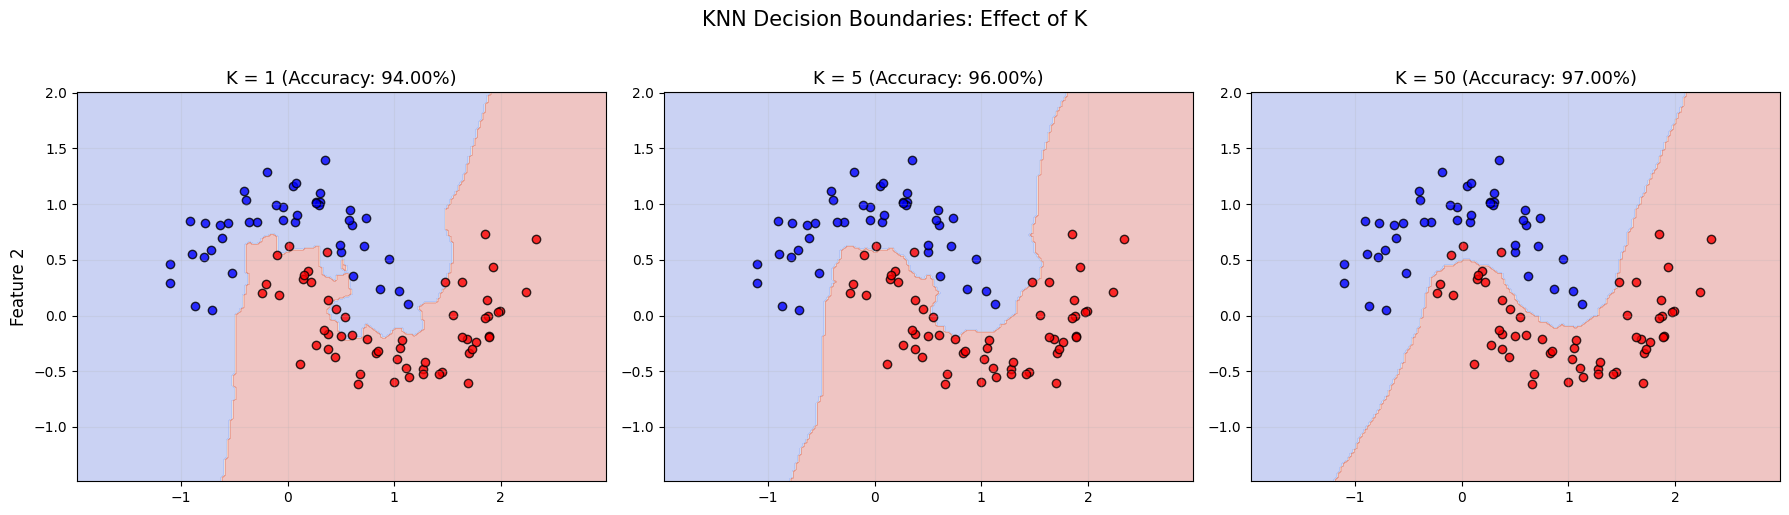

In [17]:
# Visualize decision boundaries for different K values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_values = [1, 5, 50]

xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, k in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    Z = knn.predict(grid).reshape(xx.shape)
    acc = accuracy_score(y_test, knn.predict(X_test))

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], c='blue', edgecolors='k', alpha=0.8)
    ax.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], c='red', edgecolors='k', alpha=0.8)
    ax.set_title(f'K = {k} (Accuracy: {acc:.2%})', fontsize=13)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Feature 2', fontsize=12)
plt.suptitle('KNN Decision Boundaries: Effect of K', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**What to notice:**
- **K=1**: Extremely jagged, noisy boundary. Every single training point creates its own tiny region. Classic **overfitting**.
- **K=5**: Smooth enough to generalize, but detailed enough to capture the moon shape. The sweet spot.
- **K=50**: Way too smooth. The boundary is so generalized that it starts to **underfit** — it can't even capture the basic moon shape anymore.

---
## 8. Finding the Best K

Let's systematically test all K values from 1 to 40 and plot the accuracy.

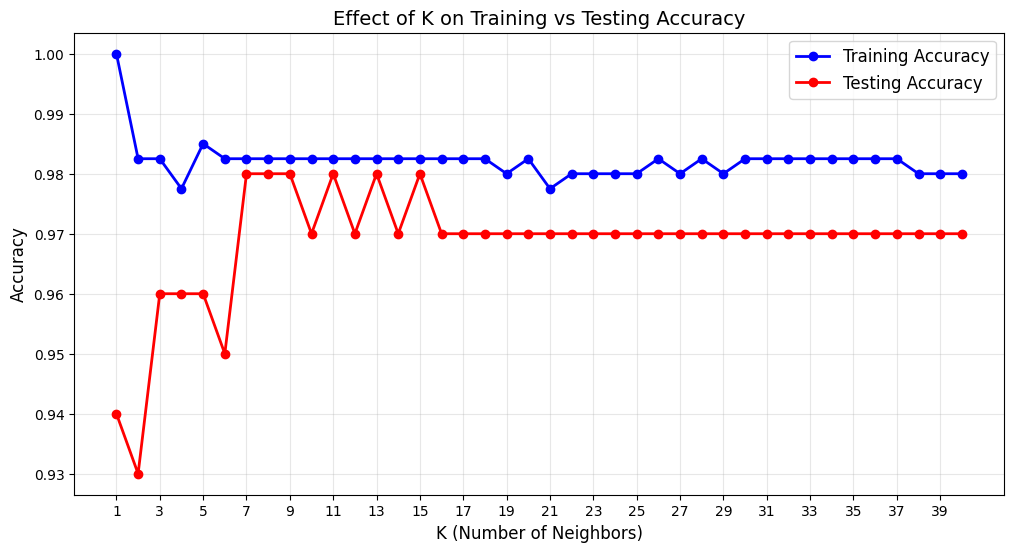

Best K: 7 with Test Accuracy: 98.00%


In [18]:
k_range = range(1, 41)
train_accs = []
test_accs = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accs.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(k_range, train_accs, 'o-', color='blue', linewidth=2, label='Training Accuracy')
plt.plot(k_range, test_accs, 'o-', color='red', linewidth=2, label='Testing Accuracy')
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of K on Training vs Testing Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 41, 2))
plt.show()

best_k = list(k_range)[np.argmax(test_accs)]
print(f"Best K: {best_k} with Test Accuracy: {max(test_accs):.2%}")

Notice how at **K=1**, training accuracy is literally 100% (because each point's nearest neighbor is itself!), but testing accuracy is lower. As K increases, training accuracy drops but testing accuracy initially improves — then it too starts dropping when K gets too large.

---
## 9. The Critical Flaw: Feature Scaling is MANDATORY

Because KNN is entirely based on **distance**, the scale of your features matters enormously.

Imagine two features:
- `Salary`: ranges from 30,000 to 150,000
- `Age`: ranges from 18 to 65

Without scaling, a salary difference of 1,000 would completely dominate an age difference of 10, even though both might be equally important. The distance formula would be almost entirely driven by Salary, making Age nearly invisible.

In [19]:
from sklearn.preprocessing import StandardScaler

# Create a deliberately badly-scaled dataset
np.random.seed(42)
n = 200
salary = np.random.uniform(30000, 150000, n)  # Huge range
age = np.random.uniform(18, 65, n)             # Small range
# Label: 1 if (age > 40 AND salary > 80000), else 0
label = ((age > 40) & (salary > 80000)).astype(int)

X_bad = np.column_stack([salary, age])
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bad, label, test_size=0.2, random_state=42)

# WITHOUT scaling
knn_noscale = KNeighborsClassifier(n_neighbors=5)
knn_noscale.fit(X_train_b, y_train_b)
acc_noscale = accuracy_score(y_test_b, knn_noscale.predict(X_test_b))

# WITH scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_b)
X_test_scaled = scaler.transform(X_test_b)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train_b)
acc_scaled = accuracy_score(y_test_b, knn_scaled.predict(X_test_scaled))

print("=" * 45)
print("  FEATURE SCALING IMPACT ON KNN")
print("=" * 45)
print(f"WITHOUT Scaling:    {acc_noscale:.2%}")
print(f"WITH Scaling:       {acc_scaled:.2%}")
print("=" * 45)
print(f"\nDifference: {(acc_scaled - acc_noscale):.2%} improvement!")

  FEATURE SCALING IMPACT ON KNN
WITHOUT Scaling:    67.50%
WITH Scaling:       100.00%

Difference: 32.50% improvement!


**Always use `StandardScaler` or `MinMaxScaler` before KNN.** This applies to any distance-based algorithm (KNN, SVM, K-Means Clustering).

---
## 10. About "Loss Functions" in KNN

**KNN has no loss function.** This sounds bizarre after studying Logistic Regression (Log Loss) and SVMs (Hinge Loss), but it's true.

There is:
- **No optimization** happening during training.
- **No weights** being learned.
- **No gradient descent**.
- **No objective function** to minimize.

KNN is a purely **instance-based** learner. It doesn't build any kind of model — it IS the data. The prediction is just a distance calculation + vote.

For **evaluation**, we still use the standard classification metrics (Accuracy, Precision, Recall, F1, Confusion Matrix).

---
## 11. When and Why: Use Cases

### Use KNN when:
- Your **dataset is small** (< 10,000 rows). KNN shines on small datasets.
- You need a **quick baseline**. KNN requires zero setup, zero tuning to get a reasonable first answer.
- The **decision boundary is highly irregular** — KNN can capture any shape.
- You're working on **recommendation systems** (e.g., "Users who are similar to you also liked...")
- **Anomaly detection** — if a point's K nearest neighbors are very far away, it's likely an anomaly.

### Avoid KNN when:
- Your dataset is **large** (> 100,000 rows). Prediction requires scanning the ENTIRE training set for every new point. This is $O(N \cdot d)$ per prediction (N = rows, d = features).
- You have **high-dimensional data** (hundreds of features). In high dimensions, "distance" becomes meaningless because all points become equidistant from each other. This is called the **Curse of Dimensionality**.
- Your features have **very different scales** and you forget to scale them.
- You need an **interpretable model**. KNN can't tell you WHY it made a prediction — it just says "because these 5 neighbors said so."

---
## 12. The Curse of Dimensionality

This is the most important theoretical concept for KNN.

Imagine you have 1 feature, and your data spans from 0 to 1 on a number line. To cover 10% of that range, you need a segment of length 0.1. Easy!

Now imagine 2 features (a 2D square). To cover 10% of the area, you need a square with side length $\sqrt{0.1} = 0.316$.

With 10 features, to cover 10% of the volume, you need a hypercube with side length $0.1^{1/10} = 0.794$.

With 100 features, you need side length $0.1^{1/100} = 0.977$ — that's basically the **entire space**!

**The math says:** As dimensions increase, the space becomes so vast that all points are basically equally far apart. "Nearest neighbors" become meaningless, because no one is truly "near" anymore.

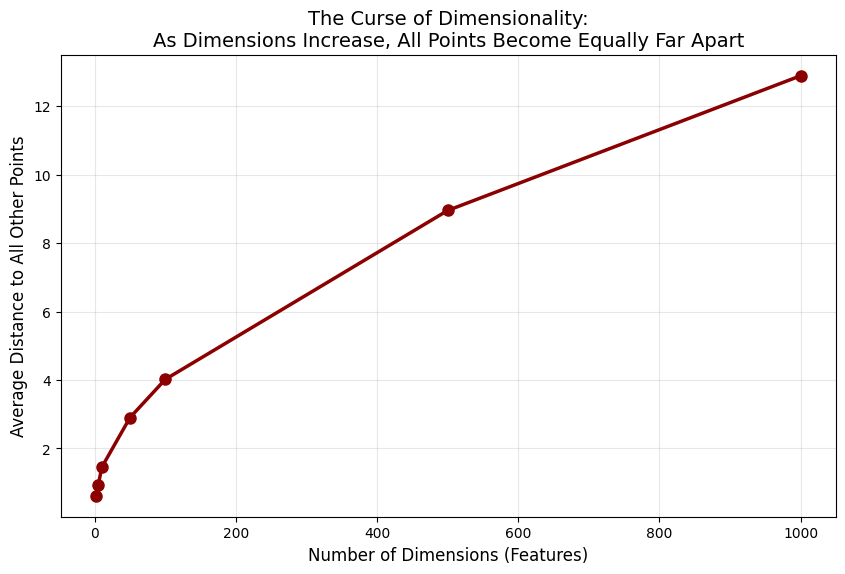

In [20]:
# Demonstrate the Curse of Dimensionality
dims = [2, 5, 10, 50, 100, 500, 1000]
avg_nn_dists = []

for d in dims:
    # Generate 100 random points in d dimensions
    points = np.random.rand(100, d)
    # Calculate distance from the first point to all others
    dists = np.sqrt(np.sum((points[0] - points[1:]) ** 2, axis=1))
    avg_nn_dists.append(np.mean(dists))

plt.figure(figsize=(10, 6))
plt.plot(dims, avg_nn_dists, 'o-', color='darkred', linewidth=2.5, markersize=8)
plt.xlabel('Number of Dimensions (Features)', fontsize=12)
plt.ylabel('Average Distance to All Other Points', fontsize=12)
plt.title('The Curse of Dimensionality:\nAs Dimensions Increase, All Points Become Equally Far Apart', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

As the number of features increases, the average distance to the nearest neighbor grows and grows. When all distances are basically the same, KNN can't distinguish "near" from "far" — and the algorithm collapses.

---
## 13. KNN vs All: The Complete Comparison

| Aspect | KNN | Decision Tree | Random Forest | Naive Bayes | Logistic Reg | SVM |
|---|---|---|---|---|---|---|
| **Training Time** | Zero (lazy) | Fast | Moderate | Very Fast | Moderate | Slow (non-linear) |
| **Prediction Time** | Very Slow | Very Fast | Fast | Very Fast | Very Fast | Fast |
| **Feature Scaling** | **Required** | Not Needed | Not Needed | Not Needed | Required | **Required** |
| **Handles Non-Linear** | Yes | Yes | Yes | Partially | No | Yes (kernel) |
| **Interpretable** | No | Very High | Low | Low | Moderate | Low |
| **Overfitting Risk** | High (low K) | Very High | Low | Very Low | Low | Moderate |
| **Best For** | Small data, baselines | Explainability | Tabular data | Text, small data | Linear boundaries | High-dim, complex |

---
## 14. Summary

| Concept | Detail |
|---|---|
| **Core Idea** | Predict by finding the K closest training points and taking a majority vote |
| **Training** | None! Just stores the data ("Lazy Learner") |
| **Loss Function** | None. No optimization, no gradients, no weights |
| **Key Hyperparameter** | `K` — number of neighbors. Low K = overfit, High K = underfit |
| **Distance Metric** | Euclidean (default), Manhattan, Minkowski |
| **Feature Scaling** | **MANDATORY** — distances are meaningless without it |
| **Biggest Strength** | Dead simple, captures any shape, great for small datasets |
| **Biggest Weakness** | Slow predictions ($O(N)$ per point), Curse of Dimensionality |
| **Best For** | Small datasets, recommendation systems, anomaly detection, quick baselines |